In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import matplotlib
import platform
import cartopy.crs as ccrs
import cartopy.io.shapereader as shapereader
import rioxarray
import glob
import pandas as pd

# set font type for PDFs and EPSs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# make switch to windows if working from home
if platform.system() == 'Windows':
    base_dir = Path('L:\malle\CLM5_CH')
else:
    base_dir = Path('/home/lud11/malle/CLM5_CH')


start by calculating hypsometry

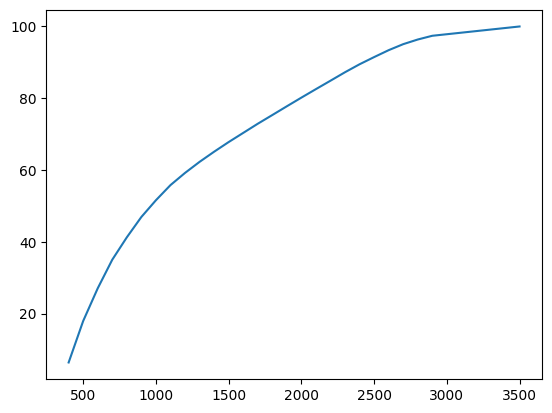

In [2]:
dem_hyp = np.hstack([150, np.arange(400, 3000, 100)])
dem_hyp_plot = np.hstack([np.arange(400, 3000, 100),3500])

dem_file = base_dir / 'BAFU_DEM_2020_1000.txt'
dem_array = rioxarray.open_rasterio(dem_file, parse_coordinates=True, masked=True)
dem_data = dem_array.squeeze()

num_all = dem_data.count().values

len_hyp = np.shape(dem_hyp)[0]
hypsom=np.zeros(len_hyp)
ids_hyp = []
for six in range(len_hyp):
    if six == len_hyp-1:
        hypsom[six] = (np.sum(dem_data > dem_hyp[six]).data / num_all) * 100
        ids_hyp.append((dem_data > dem_hyp[six]).data)
    else:
        hypsom[six] = (np.sum(((dem_data > dem_hyp[six]).data & (dem_data <= dem_hyp[six+1]).data)) / num_all) *100
        ids_hyp.append(((dem_data > dem_hyp[six]).data & (dem_data <= dem_hyp[six+1]).data))

hypsom_cum = np.cumsum(hypsom)

# need to load an output file here so we can apply OSHD mask to DEM
fig, ax = plt.subplots()
ax.plot(dem_hyp_plot, hypsom_cum)


now create dataframe for 2017 - 2018 season (all CLM5 simulations + FSM, per hypsometry elevation)

In [3]:
year_int = 2019
run_in_all_1km = ['CRUJRA_FILES_noLapse_OLD', 'CRUJRA_FILES_noLapse',
                  'CRUJRA_FILES_OLD', 'CRUJRA_FILES', 'OSHD_FILES_OLD', 'OSHD_FILES']
name_in_all = ['SNOW_DEPTH_SP_CRUJRA_noLapse.nc', 'SNOW_DEPTH_SP_CRUJRA_noLapse.nc',
               'SNOW_DEPTH_SP_CRUJRA.nc', 'SNOW_DEPTH_SP_CRUJRA.nc',
               'SNOW_DEPTH_SP_OSHD.nc', 'SNOW_DEPTH_SP_OSHD.nc']
CLM5_dec = []
CLM5_feb = []
CLM5_apr = []
for num_in, run_in in enumerate(run_in_all_1km):
    name_in = name_in_all[num_in]
    file_out = base_dir / run_in / 'HS_hyps.nc'
    if file_out.is_file():
        snow_in_sel = xr.open_dataset(file_out)
    else:
        snow_in = xr.open_dataset(base_dir / run_in / name_in)
        snow_in_sel = snow_in.sel(time=(snow_in.time.dt.month.isin([12, 2, 4]) & (snow_in.time.dt.day == 1)))
        snow_in_sel.to_netcdf(file_out)
    print('done with ' + run_in)

    mean_dec = []
    mean_feb = []
    mean_apr = []
    for six in range(len_hyp):
        ids_in = ids_hyp[six]
        dec = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 12)
                                             &(snow_in_sel.time.dt.year == year_int-1)).DATA.squeeze().values)
        mean_dec.append(np.nanmean(dec[ids_in]))

        feb = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 2)
                                             &(snow_in_sel.time.dt.year == year_int)).DATA.squeeze().values)
        mean_feb.append(np.nanmean(feb[ids_in]))

        apr = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 4)
                                             &(snow_in_sel.time.dt.year == year_int)).DATA.squeeze().values)
        mean_apr.append(np.nanmean(apr[ids_in]))

    data_c = {run_in: mean_dec}
    CLM5_dec.append(pd.DataFrame(data_c))
    data_c = {run_in: mean_feb}
    CLM5_feb.append(pd.DataFrame(data_c))
    data_c = ({run_in: mean_apr})
    CLM5_apr.append(pd.DataFrame(data_c))

bf_fsm = base_dir / 'FSM_new/analysed_grid_python_out'

if year_int == 2018:
    if (bf_fsm / 'snow_2018_hyps.nc').is_file():
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2018_hyps.nc')
    else:
        FSM_2018 = xr.open_dataset(bf_fsm / 'analysis_2018_1km.nc')
        FSM_int_2018 = FSM_2018.sel(time=(FSM_2018.time.dt.month.isin([12, 2, 4]) & (FSM_2018.time.dt.day == 1)))
        FSM_int_2018.to_netcdf(bf_fsm / 'snow_2018_hyps.nc')
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2018_hyps.nc')
elif year_int == 2019:
    if (bf_fsm / 'snow_2019_hyps.nc').is_file():
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2019_hyps.nc')
    else:
        FSM_2019 = xr.open_dataset(bf_fsm / 'analysis_2019_1km.nc')
        FSM_int_2019 = FSM_2019.sel(time=(FSM_2019.time.dt.month.isin([12, 2, 4]) & (FSM_2019.time.dt.day == 1)))
        FSM_int_2019.to_netcdf(bf_fsm / 'snow_2019_hyps.nc')
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2019_hyps.nc')

FSM_mean_dec = []
FSM_mean_feb = []
FSM_mean_apr = []

for six in range(len_hyp):
    ids_in = ids_hyp[six]
    dec = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 12)).DATA.squeeze().values)
    FSM_mean_dec.append(np.nanmean(dec[ids_in]))
    feb = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 2)).DATA.squeeze().values)
    FSM_mean_feb.append(np.nanmean(feb[ids_in]))
    apr = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 4)).DATA.squeeze().values)
    FSM_mean_apr.append(np.nanmean(apr[ids_in]))

data_c = {'FSM': FSM_mean_dec}
CLM5_dec.append(pd.DataFrame(data_c))
data_c = {'FSM': FSM_mean_feb}
CLM5_feb.append(pd.DataFrame(data_c))
data_c = ({'FSM': FSM_mean_apr})
CLM5_apr.append(pd.DataFrame(data_c))

hs_apr_all = pd.concat(CLM5_apr, axis=1).set_index(dem_hyp_plot)
hs_feb_all = pd.concat(CLM5_feb, axis=1).set_index(dem_hyp_plot)
hs_dec_all = pd.concat(CLM5_dec, axis=1).set_index(dem_hyp_plot)

done with CRUJRA_FILES_noLapse_OLD
done with CRUJRA_FILES_noLapse
done with CRUJRA_FILES_OLD
done with CRUJRA_FILES
done with OSHD_FILES_OLD
done with OSHD_FILES


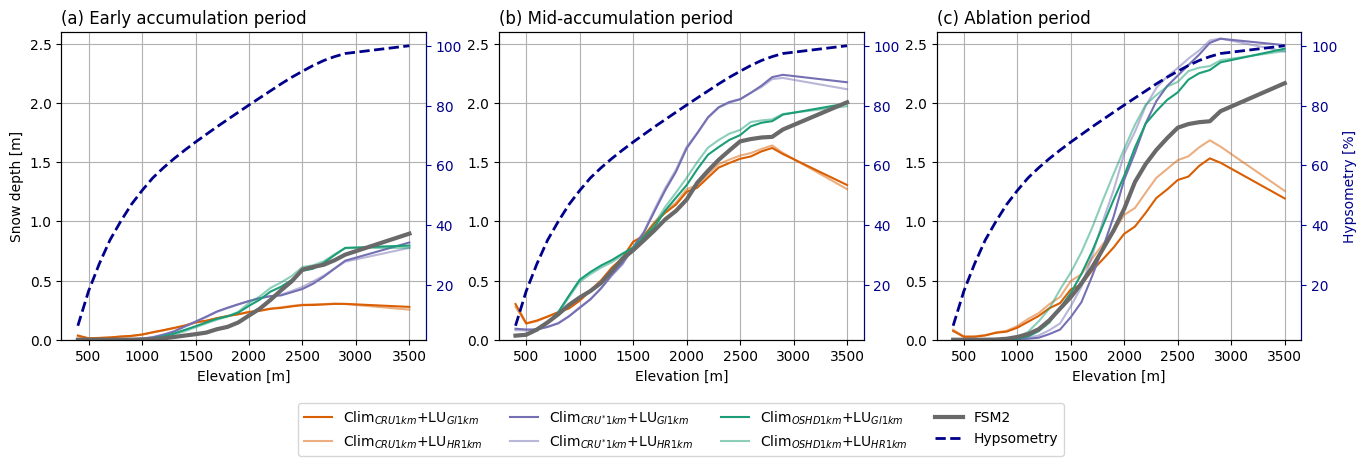

In [36]:
my_pal = {"CRUJRA_FILES_noLapse_OLD": (217/255, 95/255, 2/255), "CRUJRA_FILES_noLapse": (217/255, 95/255, 2/255),
          "CRUJRA_FILES_OLD": (117/255, 112/255, 179/255), "CRUJRA_FILES": (117/255, 112/255, 179/255),
          "OSHD_FILES_OLD": (27/255, 158/255, 119/255), "OSHD_FILES": (27/255, 158/255, 119/255),
          "FSM": "dimgray"}


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
#fig.suptitle('Season ' + str(year_int-1) + '/' + str(year_int))
hs_dec_all.plot(ax=ax1, legend=False, color=my_pal)
hs_feb_all.plot(ax=ax2, color=my_pal)
hs_apr_all.plot(ax=ax3, legend=False, color=my_pal)
ax1.grid()
ax2.grid()
ax3.grid()
ax1.set_title('(a) Early accumulation period', loc='left')
ax2.set_title('(b) Mid-accumulation period', loc='left')
ax3.set_title('(c) Ablation period', loc='left')

for patch in ax1.lines[1:-1:2]:
    patch.set_alpha(0.5)

for patch in ax2.lines[1:-1:2]:
    patch.set_alpha(0.5)

for patch in ax3.lines[1:-1:2]:
    patch.set_alpha(0.5)

ax1.lines[-1].set_linewidth(3)
ax2.lines[-1].set_linewidth(3)
ax3.lines[-1].set_linewidth(3)

ax1.set_xlabel('Elevation [m]')
ax2.set_xlabel('Elevation [m]')
ax3.set_xlabel('Elevation [m]')

ax1.set_ylabel('Snow depth [m]')
ax1a = ax1.twinx()
ax1a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')

ax2a = ax2.twinx()
ls2 = ax2a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')
labels_new = [r'Clim$_{CRU 1km}$+LU$_{Gl 1km}$', r'Clim$_{CRU 1km}$+LU$_{HR 1km}$',
              r"Clim$_{CRU^{*} 1km}$+LU$_{Gl 1km}$", r"Clim$_{CRU^{*} 1km}$+LU$_{HR 1km}$",
              r"Clim$_{OSHD 1km}$+LU$_{Gl 1km}$", r"Clim$_{OSHD 1km}$+LU$_{HR 1km}$", 'FSM2', 'Hypsometry']

lns = ax2.lines+ls2

ax2.legend(lns, labels_new, bbox_to_anchor=(0.5, -0.4), loc='lower center', ncol=4)

ax3a = ax3.twinx()
ax3a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')
ax3a.set_ylabel('Hypsometry [%]', color='darkblue')

ax1a.spines["right"].set_edgecolor('darkblue')
ax1a.tick_params(axis='y', colors='darkblue')

ax2a.spines["right"].set_edgecolor('darkblue')
ax2a.tick_params(axis='y', colors='darkblue')

ax3a.spines["right"].set_edgecolor('darkblue')
ax3a.tick_params(axis='y', colors='darkblue')
ax1.set_ylim([0, 2.6])
ax2.set_ylim([0, 2.6])
ax3.set_ylim([0, 2.6])

#plt.tight_layout()
fig.savefig(base_dir / 'figures_revisions' / Path('hypsom_'+str(year_int)+'_sameY.png'), facecolor='white', transparent=False, bbox_inches='tight')

In [32]:


lns = ax2.lines+ls2
lns





In [17]:
labels_new = [r'Clim$_{CRU 1km}$+LU$_{Gl 1km}$', r'Clim$_{CRU 1km}$+LU$_{HR 1km}$',
              r"Clim$_{CRU^{*} 1km}$+LU$_{Gl 1km}$", r"Clim$_{CRU^{*} 1km}$+LU$_{HR 1km}$",
              r"Clim$_{OSHD 1km}$+LU$_{Gl 1km}$", r"Clim$_{OSHD 1km}$+LU$_{HR 1km}$", 'FSM2']

In [ ]:
label_in = ['FSM', 'Clim$_{CRU0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$', 'Clim$_{CRU^{*}0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$',
            'Clim$_{OSHD0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$',
            'Clim$_{CRU0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$', 'Clim$_{CRU^{*}0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$',
            'Clim$_{OSHD0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$',
            'Clim$_{CRU1km}$+LU$_{Gl1km}$', 'Clim$_{CRU1km}$+LU$_{HR1km}$',
            'Clim$_{CRU^{*}1km}$+LU$_{Gl1km}$', 'Clim$_{CRU^{*}1km}$+LU$_{HR1km}$',
            'Clim$_{OSHD1km}$+LU$_{Gl1km}$', 'Clim$_{OSHD1km}$+LU$_{HR1km}$'
            ]